<h2>Utils</h2>

In [25]:
import sys
import os

import numpy
from fetch_movie_details import search_movie, get_movie_details, discover_movies, get_genre_mapping
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from fetch_movie_details import discover_movies
import pandas as pd

movies = discover_movies(page=1)

# Convert to DataFrame
df = pd.json_normalize(movies)

# Show just what you want
print(df[['title', 'release_date', 'vote_average']].head())
print(df.columns)
#print(df['genre_ids'])

                      title release_date  vote_average
0         War of the Worlds   2025-07-29         4.504
1  How to Train Your Dragon   2025-06-06         8.044
2            28 Years Later   2025-06-18         6.934
3             Lilo & Stitch   2025-05-17         7.333
4                 M3GAN 2.0   2025-06-25         7.667
Index(['adult', 'backdrop_path', 'genre_ids', 'id', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'release_date', 'title', 'video', 'vote_average', 'vote_count'],
      dtype='object')


<h2>Data Loading</h2>

In [27]:
def get_movie_data(max_pages):
    full_data = []
    for count in range(1, max_pages+1):
        for movie in discover_movies(page=count):  # or across multiple pages
            movie_id = movie['id']
            details = get_movie_details(movie_id)
            full_data.append(details)
        
        df = pd.json_normalize(full_data)
        df.to_csv('../data/movies_full.csv', index=False)


In [28]:
csv_path = "../data/movies_full.csv"
download_more_data = False

if os.path.exists(csv_path): #and not download_more_data:
    print("Already obtained data")
else:
    n = 50
    movie_df = get_movie_data(n)
    print("Obtained data!")

Already obtained data


In [29]:
# Useful columns: adult, budget, genres, origin country, original language, tagline, title, vote average, overview, popularity, revenue, runtime
csv_path = "../data/movies_full.csv"
movies = pd.read_csv(csv_path)
movies.head(1)

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,/iZLqwEwUViJdSkGVjePGhxYzbDb.jpg,NaN,250,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",https://www.amazon.com/gp/video/detail/B0DMF7MXKT,755898,tt13186306,['US'],en,...,Released,Your data is deadly.,War of the Worlds,False,4.496,119,NaN,NaN,NaN,NaN


In [30]:
movies.columns

Index(['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres',
       'homepage', 'id', 'imdb_id', 'origin_country', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'belongs_to_collection.id',
       'belongs_to_collection.name', 'belongs_to_collection.poster_path',
       'belongs_to_collection.backdrop_path'],
      dtype='object')

In [31]:
movies.overview.head()

0    Will Radford is a top cyber-security analyst f...
1    On the rugged isle of Berk, where Vikings and ...
2    Twenty-eight years since the rage virus escape...
3    The wildly funny and touching story of a lonel...
4    After the underlying tech for M3GAN is stolen ...
Name: overview, dtype: object

<h2>Data Visualization</h2>

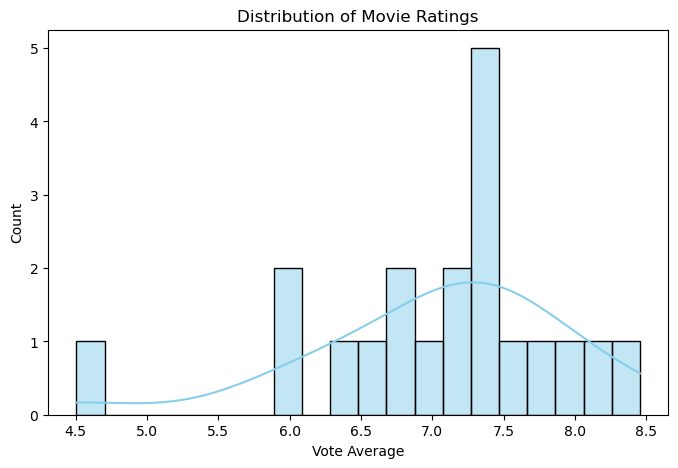

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df["vote_average"], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Count")
plt.show()

In [33]:
genre_map = get_genre_mapping()

In [34]:
def map_genre_ids_to_names(genre_ids_list):
    return [genre_map.get(genre_id, "Unknown") for genre_id in genre_ids_list]

df["genre_names"] = df["genre_ids"].apply(map_genre_ids_to_names)

In [35]:
print(df[["title", "genre_names"]].head())

                      title                                   genre_names
0         War of the Worlds                   [Science Fiction, Thriller]
1  How to Train Your Dragon                     [Fantasy, Family, Action]
2            28 Years Later           [Horror, Thriller, Science Fiction]
3             Lilo & Stitch  [Family, Science Fiction, Comedy, Adventure]
4                 M3GAN 2.0           [Action, Science Fiction, Thriller]


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(movies['overview'])

# Compute Cosine Similarity
similarity_matrix = cosine_similarity(tfidf_matrix)

In [46]:
def recommend(title, top_n=5):
    if title not in movies['title'].values:
        return f"'{title}' not found in the dataset."
    idx = movies[movies['title'] == title].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx]  # exclude the movie itself
    top_indices = [i[0] for i in sim_scores[:top_n]]
    return movies['title'].iloc[top_indices].tolist()

In [50]:
print("\nRecommendations for a sample movie:")
print(recommend(movies['title'].iloc[3]))


Recommendations for a sample movie:
['Lilo & Stitch', 'Life Is Beautiful', 'Paris, Texas', 'Mad Max: Fury Road', 'Alice in Wonderland']
